# How weather moves Citibike ridership — daily and hourly

*An analysis of how New York's weather shapes Citibike demand, 2013 → present, across
two time grains: the **daily** record (4.7k days) and the **hourly** record (114k clock
hours). It pairs descriptive views with a regression-based **attribution** that isolates
each weather factor's own effect — the design choices are spelled out as they go.*

Everything here is built **from scratch** in the notebook — we pull the trips-and-weather
tables and construct each regression step by step, so the modeling choices are visible and
auditable rather than hidden behind a library call. (The same logic is *also* packaged in
`dashboard/attribution.py` for the live Streamlit app, but this notebook does not import it
— it derives the models itself.) The plots are static snapshots.

## The question, and why it needs two grains

Ridership obviously rises in summer and falls in winter — but "warm months are busy" is
not the same statement as "warmth *causes* rides," because warm days are also long days,
dry days, holiday-season days. The job here is to separate a weather factor's **own**
contribution from everything that travels with it. Two grains do different parts of that job:

- **Daily** owns the **level** effects — temperature bands, daily rain totals, snow on the
  ground, wind, humidity. These are identified from *day-to-day* variation: a cold snap in
  an otherwise mild month, a rainy Tuesday next to a dry one.
- **Hourly** owns the **timing** effects — what happens *in the very hour* rain starts.
  Rain arrives at essentially random times of day, so "the raining hour vs. a dry hour of
  the *same* day" is a clean within-day quasi-experiment that the daily grain can't see.

## Data sources

Two BigQuery views in `nyu-datasets`, both already joining trips to the matching Central
Park weather record:

| View | Grain | What |
|---|---|---|
| `citibike.daily_trips_weather` | one row / local calendar day | `m_daily_trips` ⨝ `weather.m_weather_daily_nyc` (GHCN-Daily) |
| `citibike.hourly_trips_weather` | one row / local clock hour | `m_hourly_trips` ⨝ `weather.m_weather_hourly_nyc` (NOAA LCD v2 hourly) |

Both use Citibike's **local** (America/New_York) wall-clock keys, so rain lines up with the
hour it actually fell. We analyze the **NYC** region throughout (weather is measured in
Central Park, so the NYC slice is the cleanest signal; Jersey City is available too).

> **Auth.** The cells below construct a `bigquery.Client` via Application Default
> Credentials. In this repo's sessions that's the `claude-agent` service account; locally
> use `gcloud auth application-default login` or set `GOOGLE_APPLICATION_CREDENTIALS`.

## The methodology in one paragraph

The descriptive sections answer *"how does a day like this compare to its surrounding
month?"* — honest about growth and season, but still **marginal**: a windy day is also a
cold day, so the comparison credits the whole drop to whichever variable you're looking at.
The **attribution** sections fix that by fitting *one* model and reading each coefficient
with the others held constant. At the daily grain that's `log(trips) ~ month FE + day-of-week
+ holidays + all weather`, with Newey–West (HAC) standard errors. At the hourly grain the
controls saturate one level further — a fixed effect for **every calendar day** — so rain
is identified purely *within* the day. We assemble both models below with `statsmodels`,
spelling out the design matrix, the fixed-effects absorption, and the standard-error choice
at each step.

## 0 · Setup — imports and data

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from google.cloud import bigquery

# statsmodels is the modeling toolkit for the whole notebook. We build every
# regression by hand (no project imports), so the design stays on the page.
import statsmodels.api as sm                                 # OLS with robust covariances
import statsmodels.formula.api as smf                        # R-style model formulas
from statsmodels.nonparametric.smoothers_lowess import lowess  # assumption-free trend line
from pandas.tseries.holiday import USFederalHolidayCalendar  # to flag US holidays

A small amount of shared plotting setup — a consistent palette and a tidy axis formatter.

In [2]:
# Show every figure inline as a crisp static image, with thin grey gridlines.
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.autolayout": True,
})

# A colour-blind-friendly palette, named so the plotting code reads in plain English.
NAVY   = "#1F4E96"
RED    = "#E45756"
BLUE   = "#4C78A8"
GREEN  = "#54A24B"
PURPLE = "#B279A2"
TEAL   = "#72B7B2"
ORANGE = "#F58518"
SEASON_COLOURS = {"Winter": BLUE, "Spring": GREEN, "Summer": RED, "Fall": ORANGE}

# Axis tick formatter: show 12,500 as "12k" so trip counts read at a glance.
def thousands_formatter(value, _pos):
    return f"{value/1e3:.0f}k" if value >= 1e3 else f"{value:.0f}"

thousands = FuncFormatter(thousands_formatter)

Open the BigQuery client (Application Default Credentials).

In [3]:
PROJECT = "nyu-datasets"
client = bigquery.Client(project=PROJECT)
print("BigQuery client ready — project:", client.project)

BigQuery client ready — project: nyu-datasets


### Load the daily table

One row per local calendar day, trips already joined to NYC weather. We focus on the **NYC**
region (the columns suffixed `_nyc`) because the weather is a Central Park measurement, so
NYC is the cleanest match. BigQuery returns integer columns as pandas *nullable* `Int64`;
the modeling math wants plain `float64` (with missing values as `NaN`), so we coerce the
numeric columns up front.

In [4]:
daily = (
    client.query("SELECT * FROM `nyu-datasets.citibike.daily_trips_weather` ORDER BY date")
          .to_dataframe()
)
daily["date"] = pd.to_datetime(daily["date"])

# The three ridership columns we model, named once so the rest of the notebook is readable.
TRIPS  = "num_nyc_trips"          # all NYC trips that day
MEMBER = "num_member_trips_nyc"   # ... by annual members (commuters)
CASUAL = "num_casual_trips_nyc"   # ... by casual riders (single-ride / day-pass)

# Coerce counts and weather drivers to float64 (nullable Int64 -> float, pd.NA -> NaN).
numeric_columns = [
    TRIPS, MEMBER, CASUAL,
    "tavg_f", "prcp_inches", "snow_inches", "snow_depth_inches",
    "wind_avg_mph", "dewpoint_f", "is_thunder", "is_foggy",
]
for column in numeric_columns:
    daily[column] = pd.to_numeric(daily[column], errors="coerce").astype("float64")

# NYC service began June 2013; drop the empty pre-launch rows.
daily = daily[daily[TRIPS] > 0].copy()

# Casual share of the day's trips — the most weather-sensitive slice of demand.
daily["casual_share"] = daily[CASUAL] / daily[TRIPS] * 100

print(f"{len(daily):,} NYC days, "
      f"{daily['date'].min():%Y-%m-%d} -> {daily['date'].max():%Y-%m-%d}")
print(f"{daily[TRIPS].sum()/1e6:,.1f}M trips total")
daily[["date", TRIPS, "tavg_f", "prcp_inches", "wind_avg_mph"]].head()

/home/user/citibike-example/.venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


4,738 NYC days, 2013-06-01 -> 2026-05-31
311.5M trips total


,date,num_nyc_trips,tavg_f,prcp_inches,wind_avg_mph
0,2013-06-01,8722.0,81.5,0.00,3.8
1,2013-06-02,15971.0,78.5,0.85,6.0
2,2013-06-03,7598.0,72.0,0.87,3.4
3,2013-06-04,15782.0,66.0,0.00,4.9
4,2013-06-05,15690.0,65.9,0.00,3.8


### A detrended "ridership index"

Several weather factors are themselves seasonal — winter is colder **and** windier, mugginess
rides with summer heat. To look at those factors descriptively without the seasons doing the
talking, we express each day's trips as a percentage of its **surrounding ~month's** typical
volume: the day's count divided by a centered 29-day median, times 100. That ratio nets out
both the long-term growth trend and the seasonal level, so 100 means "a normal day for this
time of year." (The Section 3 regression handles this more rigorously; the index is just for
the descriptive Wind and Humidity views.)

In [5]:
daily_series = daily.set_index("date")[TRIPS].sort_index()

# Centered 29-day median ~ the local seasonal "normal" level around each day.
local_normal = daily_series.rolling(29, center=True, min_periods=10).median()

ridership_index = (daily_series / local_normal) * 100
daily["ridership_index"] = ridership_index.values
daily[["date", TRIPS, "ridership_index"]].head()

,date,num_nyc_trips,ridership_index
0,2013-06-01,8722.0,58.372373
1,2013-06-02,15971.0,104.276574
2,2013-06-03,7598.0,48.425749
3,2013-06-04,15782.0,103.042570
4,2013-06-05,15690.0,100.000000


### Load the hourly table

One row per local **clock hour**. Note an important quirk: an hour with *zero* trips has no
row at all in the mart. We keep that in mind below — wherever we average over hours of the
day, we first zero-fill the complete `(date × 24h)` grid so empty overnight hours aren't
silently skipped.

In [6]:
hourly_columns = (
    "date, hour, num_nyc_trips, num_member_trips_nyc, num_casual_trips_nyc, "
    "temp_f, prcp_inches, is_raining, is_snowing"
)
hourly = (
    client.query(f"SELECT {hourly_columns} FROM `nyu-datasets.citibike.hourly_trips_weather`")
          .to_dataframe()
)
hourly["date"] = pd.to_datetime(hourly["date"])

# Same nullable-Int64 -> float64 coercion as the daily table.
for column in hourly.columns.drop("date"):
    hourly[column] = pd.to_numeric(hourly[column], errors="coerce").astype("float64")
hourly["hour"] = hourly["hour"].astype(int)   # 0..23, used as a join/grid key

print(f"{len(hourly):,} hourly observations (zero-trip hours are absent from the mart)")
hourly.head()

/home/user/citibike-example/.venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


113,559 hourly observations (zero-trip hours are absent from the mart)


,date,hour,num_nyc_trips,num_member_trips_nyc,num_casual_trips_nyc,temp_f,prcp_inches,is_raining,is_snowing
0,2013-11-13,0,142.0,142.0,0.0,30.9,0.000,0.0,0.0
1,2013-12-12,0,149.0,149.0,0.0,28.9,0.000,0.0,0.0
2,2013-12-15,0,23.0,23.0,0.0,35.1,0.280,1.0,0.0
3,2014-01-03,0,15.0,15.0,0.0,16.0,0.059,0.0,1.0
4,2014-01-04,0,18.0,18.0,0.0,9.0,0.000,0.0,0.0


## 1 · The big picture

Ridership grows year over year (the network keeps expanding) while oscillating with the
seasons — summer peaks, winter troughs — riding the temperature curve almost exactly.

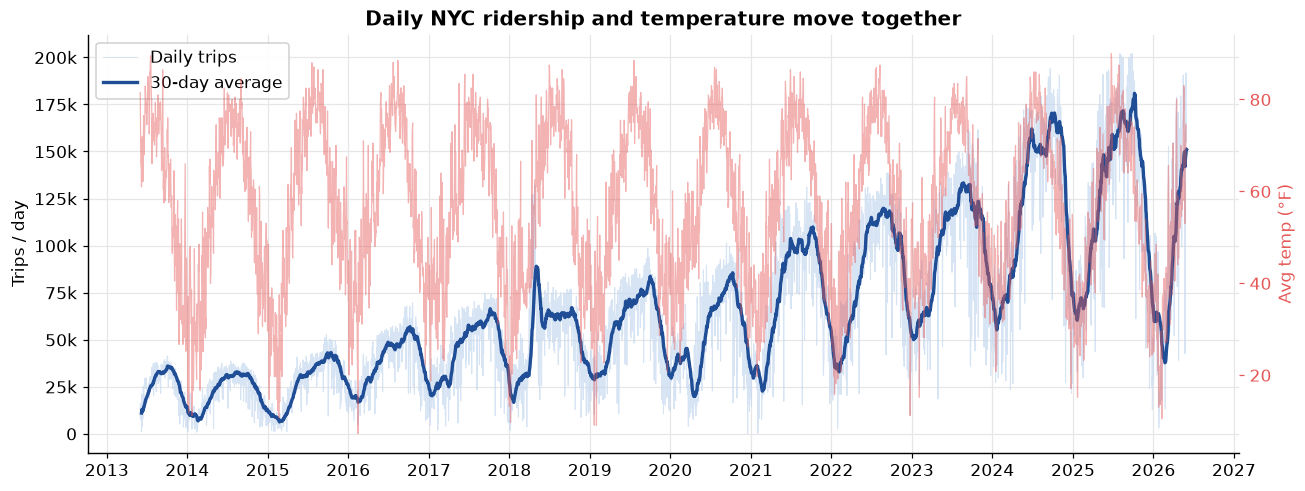

In [7]:
# Smooth the noisy daily series with a 30-day rolling mean for the trend line.
timeline = daily.set_index("date").sort_index()
timeline["trips_30d_avg"] = timeline[TRIPS].rolling("30D", min_periods=7).mean()

fig, ax_trips = plt.subplots(figsize=(12, 4.6))

# Raw daily trips (faint) plus the 30-day average (bold) on the left axis.
ax_trips.plot(timeline.index, timeline[TRIPS],
              color="#C7D9F0", lw=0.7, alpha=0.7, label="Daily trips")
ax_trips.plot(timeline.index, timeline["trips_30d_avg"],
              color=NAVY, lw=2.2, label="30-day average")
ax_trips.set_ylabel("Trips / day")
ax_trips.yaxis.set_major_formatter(thousands)
ax_trips.set_title("Daily NYC ridership and temperature move together")

# Average temperature on a second y-axis, to show how tightly the two track.
ax_temp = ax_trips.twinx()
ax_temp.grid(False)
ax_temp.plot(timeline.index, timeline["tavg_f"],
             color=RED, lw=0.8, alpha=0.45, label="Avg temp (°F)")
ax_temp.set_ylabel("Avg temp (°F)", color=RED)
ax_temp.tick_params(axis="y", colors=RED)

ax_trips.xaxis.set_major_locator(mdates.YearLocator())
ax_trips.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_trips.legend(loc="upper left", framealpha=0.9)
plt.show()

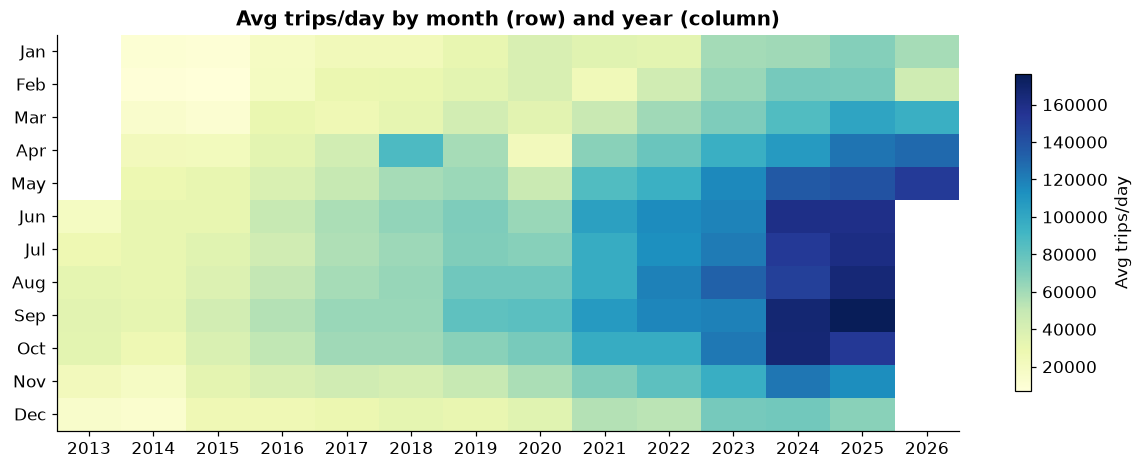

In [8]:
# Month x year grid of average daily trips: rows = month, columns = year.
month_by_year = (
    daily.assign(month=daily["date"].dt.month, year=daily["date"].dt.year)
         .pivot_table(index="month", columns="year", values=TRIPS, aggfunc="mean")
         .reindex(range(1, 13))            # always 12 rows so month labels line up
)

fig, ax = plt.subplots(figsize=(11, 4.4))
heatmap = ax.imshow(month_by_year.values, aspect="auto", cmap="YlGnBu", origin="upper")
ax.set_xticks(range(month_by_year.shape[1]))
ax.set_xticklabels(month_by_year.columns)
ax.set_yticks(range(12))
ax.set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Avg trips/day by month (row) and year (column)")
ax.grid(False)
fig.colorbar(heatmap, ax=ax, shrink=0.8, label="Avg trips/day")
plt.show()

The vertical gradient is the weather/seasonal cycle (summer bright, winter dark); the
left-to-right brightening is the network's growth. The two are entangled in every raw
number — which is exactly why the rest of this notebook works to pull them apart.

## 2 · Descriptive daily relationships

First the *marginal* picture, one factor at a time. These views are honest about growth and
season but still bundle correlated weather — read them as "what a day like this looks like,"
not yet "what this factor does on its own." Section 3 does the isolating.

### 2.1 Temperature — more rides, up to a point

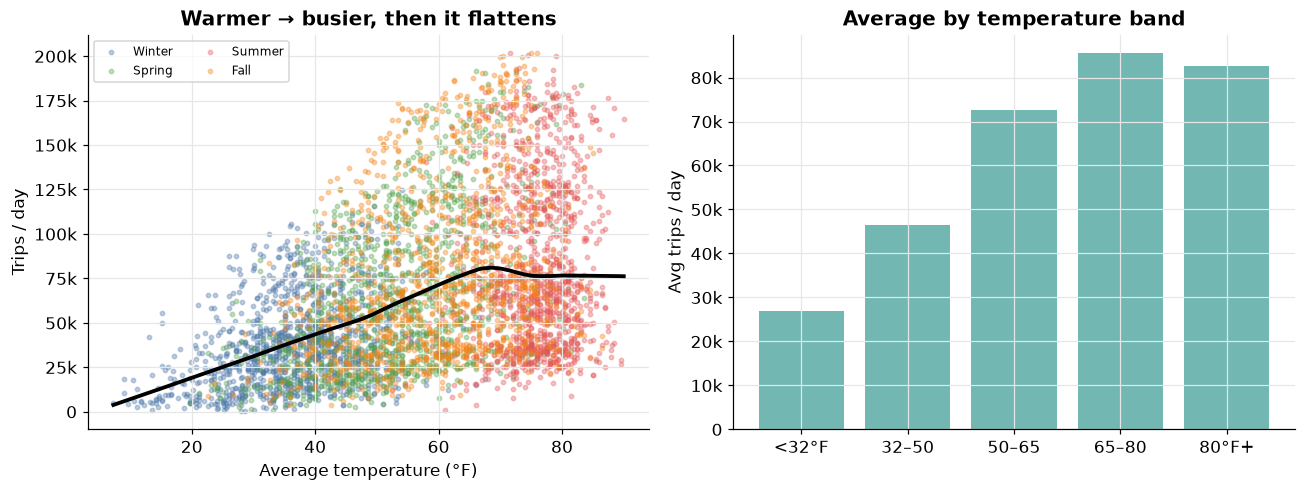

In [9]:
# Keep only days that actually carry a weather reading; reused by later cells.
weather_days = daily.dropna(subset=["tavg_f"]).copy()

fig, (ax_scatter, ax_bands) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left panel: one point per day, coloured by season, with a LOWESS trend.
for season, colour in SEASON_COLOURS.items():
    season_days = weather_days[weather_days["season"] == season]
    ax_scatter.scatter(season_days["tavg_f"], season_days[TRIPS],
                       s=8, alpha=0.35, color=colour, label=season)

# LOWESS = locally weighted regression: a smooth trend with no functional-form assumption.
temp_trend = lowess(weather_days[TRIPS], weather_days["tavg_f"],
                    frac=0.3, return_sorted=True)
ax_scatter.plot(temp_trend[:, 0], temp_trend[:, 1], color="black", lw=2.5)
ax_scatter.set_xlabel("Average temperature (°F)")
ax_scatter.set_ylabel("Trips / day")
ax_scatter.yaxis.set_major_formatter(thousands)
ax_scatter.legend(fontsize=8, ncol=2)
ax_scatter.set_title("Warmer → busier, then it flattens")

# Right panel: average ridership within five coarse temperature bands.
band_edges  = [-100, 32, 50, 65, 80, 200]
band_labels = ["<32°F", "32–50", "50–65", "65–80", "80°F+"]
temperature_band = pd.cut(weather_days["tavg_f"], band_edges, labels=band_labels)
avg_trips_by_band = weather_days.groupby(temperature_band, observed=True)[TRIPS].mean()

ax_bands.bar(range(len(avg_trips_by_band)), avg_trips_by_band.values, color=TEAL)
ax_bands.set_xticks(range(len(avg_trips_by_band)))
ax_bands.set_xticklabels(avg_trips_by_band.index)
ax_bands.set_ylabel("Avg trips / day")
ax_bands.yaxis.set_major_formatter(thousands)
ax_bands.set_title("Average by temperature band")
plt.show()

The lowess fit climbs steeply from freezing to ~75°F, then flattens and dips on the hottest
days (80°F+): riders avoid extreme heat much as they avoid the cold. The response is an
inverted-U, which is why the attribution model later **bins** temperature rather than forcing
a single straight line through it.

### 2.2 Rain dampens, snow stops

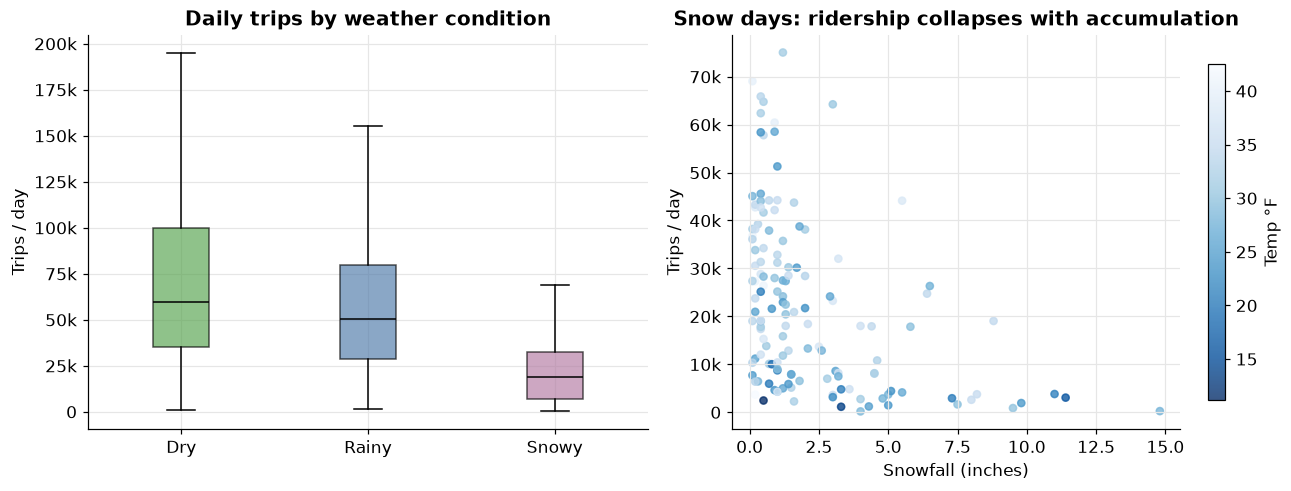

In [10]:
# Label each day's headline condition. Snow takes precedence over rain. The flags come
# back as nullable integers, so build NA-safe boolean masks before combining them.
is_snowy = weather_days["is_snowy"].eq(1).fillna(False).to_numpy(bool)
is_rainy = weather_days["is_rainy"].eq(1).fillna(False).to_numpy(bool)
is_dry   = weather_days["is_rainy"].eq(0).fillna(False).to_numpy(bool)
weather_days["condition"] = np.select(
    [is_snowy, is_rainy, is_dry],
    ["Snowy", "Rainy", "Dry"],
    default=None,
)

fig, (ax_box, ax_snow) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: distribution of daily trips in each condition (boxes, outliers hidden).
conditions = ["Dry", "Rainy", "Snowy"]
condition_colours = {"Dry": GREEN, "Rainy": BLUE, "Snowy": PURPLE}
trips_per_condition = [
    weather_days.loc[weather_days["condition"] == name, TRIPS].dropna().values
    for name in conditions
]
boxplot = ax_box.boxplot(trips_per_condition, patch_artist=True, showfliers=False)
ax_box.set_xticks(range(1, len(conditions) + 1))
ax_box.set_xticklabels(conditions)
for box, name in zip(boxplot["boxes"], conditions):
    box.set_facecolor(condition_colours[name])
    box.set_alpha(0.65)
for median_line in boxplot["medians"]:
    median_line.set_color("black")
ax_box.set_ylabel("Trips / day")
ax_box.yaxis.set_major_formatter(thousands)
ax_box.set_title("Daily trips by weather condition")

# Right: on snow days, how ridership falls as snowfall accumulates (colour = temperature).
snow_days = weather_days[weather_days["snow_inches"] > 0]
snow_scatter = ax_snow.scatter(snow_days["snow_inches"], snow_days[TRIPS],
                               c=snow_days["tavg_f"], cmap="Blues_r", s=22, alpha=0.8)
ax_snow.set_xlabel("Snowfall (inches)")
ax_snow.set_ylabel("Trips / day")
ax_snow.yaxis.set_major_formatter(thousands)
ax_snow.set_title("Snow days: ridership collapses with accumulation")
fig.colorbar(snow_scatter, ax=ax_snow, label="Temp °F", shrink=0.85)
plt.show()

A rainy day's median sits well below a dry one; a snowy day's lower still. On snow days
ridership falls as accumulation rises — the heaviest storms bring the system to a
near-standstill. And snow *on the ground* depresses riding for days **after** a storm, not
just the day it falls (the daily model carries a separate `snow_depth` term for exactly this).

### 2.3 Wind and humidity — read against the ridership index

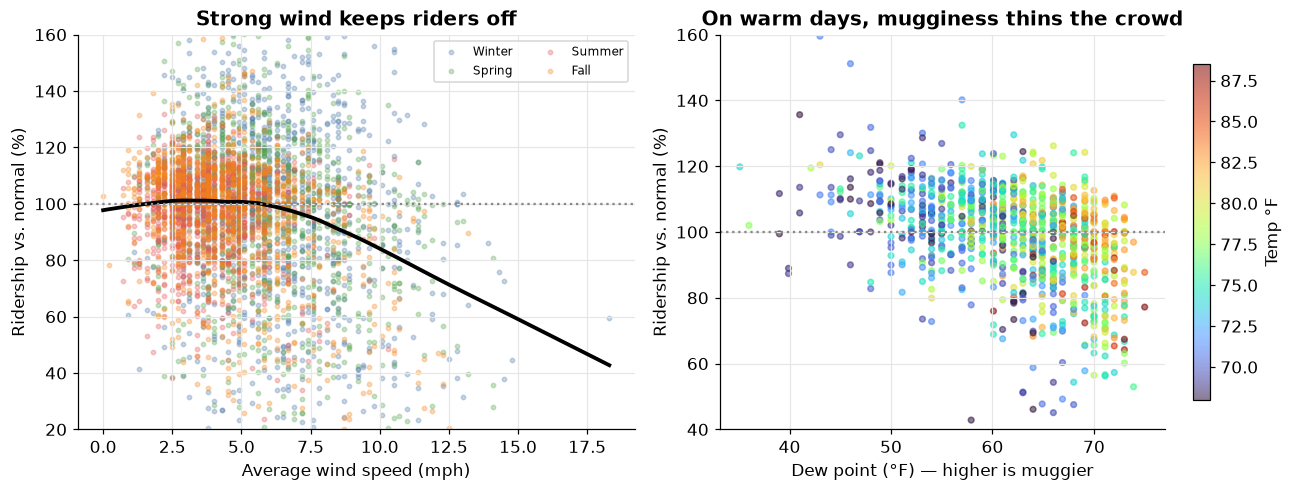

In [11]:
fig, (ax_wind, ax_humidity) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: wind vs the detrended index, so the effect is net of season
# (winter is both colder and windier, which would otherwise confound a raw plot).
wind_days = daily.dropna(subset=["wind_avg_mph", "ridership_index"])
for season, colour in SEASON_COLOURS.items():
    season_days = wind_days[wind_days["season"] == season]
    ax_wind.scatter(season_days["wind_avg_mph"], season_days["ridership_index"],
                    s=8, alpha=0.3, color=colour, label=season)
wind_trend = lowess(wind_days["ridership_index"], wind_days["wind_avg_mph"],
                    frac=0.4, return_sorted=True)
ax_wind.plot(wind_trend[:, 0], wind_trend[:, 1], color="black", lw=2.5)
ax_wind.axhline(100, ls=":", color="#888")     # 100 = a normal day for the season
ax_wind.set_xlabel("Average wind speed (mph)")
ax_wind.set_ylabel("Ridership vs. normal (%)")
ax_wind.set_ylim(20, 160)
ax_wind.legend(fontsize=8, ncol=2)
ax_wind.set_title("Strong wind keeps riders off")

# Right: dew point (the best single "muggy" gauge) on WARM days only, where it bites.
warm_days = daily.dropna(subset=["dewpoint_f", "ridership_index"])
warm_days = warm_days[warm_days["tavg_f"] >= 68]
humidity_scatter = ax_humidity.scatter(
    warm_days["dewpoint_f"], warm_days["ridership_index"],
    c=warm_days["tavg_f"], cmap="turbo", s=14, alpha=0.55,
)
ax_humidity.axhline(100, ls=":", color="#888")
ax_humidity.set_xlabel("Dew point (°F) — higher is muggier")
ax_humidity.set_ylabel("Ridership vs. normal (%)")
ax_humidity.set_ylim(40, 160)
ax_humidity.set_title("On warm days, mugginess thins the crowd")
fig.colorbar(humidity_scatter, ax=ax_humidity, label="Temp °F", shrink=0.85)
plt.show()

Both are plotted against the **ridership index** because wind and humidity are themselves
seasonal. Calm/breezy days ride near normal; past ~9 mph ridership drops, and the windiest
days run little more than half their usual volume. On warm days, oppressive dew points pull
riding ~10% below normal. Some of the wind gap is the cold that travels with it — Section 3
puts wind's *own* effect at about half this.

### 2.4 Casual riders are far more weather-sensitive than members

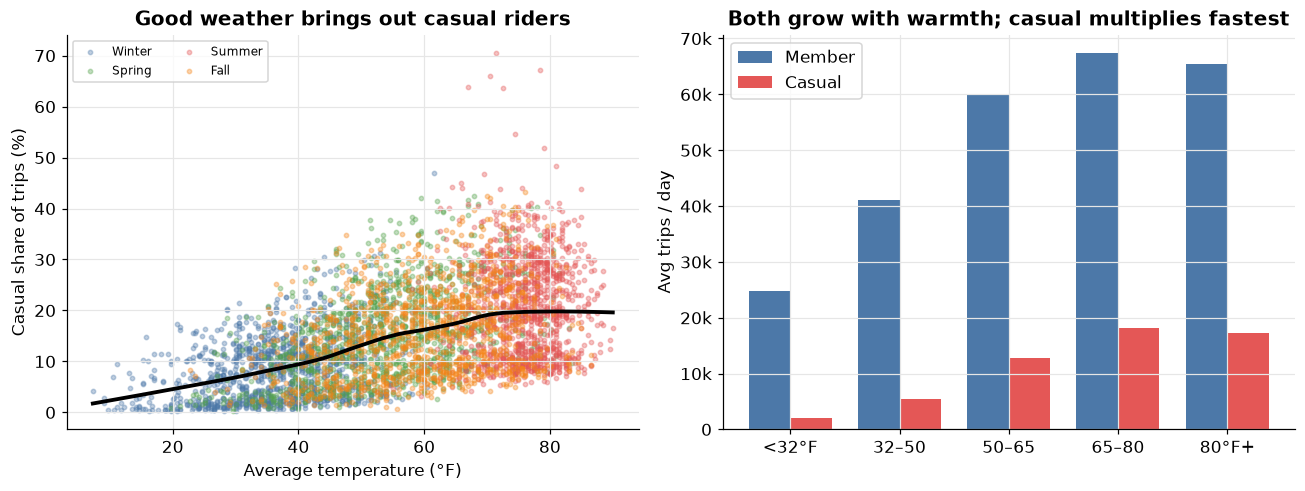

In [12]:
fig, (ax_share, ax_mix) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: the casual share of trips vs temperature (good weather brings out occasional riders).
for season, colour in SEASON_COLOURS.items():
    season_days = weather_days[weather_days["season"] == season]
    ax_share.scatter(season_days["tavg_f"], season_days["casual_share"],
                     s=8, alpha=0.35, color=colour, label=season)
share_trend = lowess(weather_days["casual_share"], weather_days["tavg_f"],
                     frac=0.3, return_sorted=True)
ax_share.plot(share_trend[:, 0], share_trend[:, 1], color="black", lw=2.5)
ax_share.set_xlabel("Average temperature (°F)")
ax_share.set_ylabel("Casual share of trips (%)")
ax_share.legend(fontsize=8, ncol=2)
ax_share.set_title("Good weather brings out casual riders")

# Right: average member vs casual trips within the same temperature bands as 2.1.
temperature_band = pd.cut(weather_days["tavg_f"], band_edges, labels=band_labels)
avg_by_band = weather_days.groupby(temperature_band, observed=True)[[MEMBER, CASUAL]].mean()
x = np.arange(len(avg_by_band))
bar_width = 0.38
ax_mix.bar(x - bar_width/2, avg_by_band[MEMBER], bar_width, label="Member", color=BLUE)
ax_mix.bar(x + bar_width/2, avg_by_band[CASUAL], bar_width, label="Casual", color=RED)
ax_mix.set_xticks(x)
ax_mix.set_xticklabels(avg_by_band.index)
ax_mix.set_ylabel("Avg trips / day")
ax_mix.yaxis.set_major_formatter(thousands)
ax_mix.legend()
ax_mix.set_title("Both grow with warmth; casual multiplies fastest")
plt.show()

The casual (non-member) share climbs steeply with temperature — good weather brings out
tourists and occasional riders, while members (commuters) ride a steadier base. This
member-vs-casual gap is more than a curiosity: in Section 5 we use it as a **validity probe**
for the causal estimates, because a real behavioral response to weather should hit
discretionary casual trips harder than committed commutes, in a pattern leftover seasonality
could not fake.

## 3 · Daily attribution — the isolated effect of each factor

The descriptive views bundle correlated weather. Here a single regression separates them:

$$\log(\text{trips}) \;\sim\; C(\text{year-month}) + C(\text{day-of-week}) + \text{holiday}
+ C(\text{temp band}) + C(\text{rain band}) + \text{snow} + \text{snow depth}
+ \text{wind} + \text{thunder} + \text{fog}$$

**The design choices, and why:**

- **Month fixed effects** absorb the growth trend, the seasonal level, and one-off shocks
  (COVID). So every weather coefficient is identified purely from variation *within* a
  calendar month — a rainy day against the dry days around it — never from "summer vs.
  winter." This is the lesson that makes the estimates causal rather than seasonal.
- **Temperature and rain enter as bins**, not slopes: temperature's effect is an inverted-U
  (Section 2.1) and rain's is concave, so a single linear term would be a lie.
- **Newey–West (HAC) standard errors**, because daily residuals are autocorrelated (a
  good-weather stretch clusters); naïve OLS errors would be too optimistic.
- Each coefficient is reported as $e^\beta - 1$ — a multiplicative **% change** in ridership.

**Step 1 — build the design matrix.** Log outcome, the calendar controls, and the binned
weather. Temperature's reference category is the mild `55–65°F` band (so every other band
reads as a contrast against comfortable weather); rain's reference is `dry`.

In [13]:
# Bin edges/labels. Listing the reference category first lets us reorder it to the
# front so statsmodels treats it as the omitted baseline.
TEMP_EDGES  = [-100, 32, 45, 55, 65, 75, 85, 200]
TEMP_LABELS = ["<32", "32-45", "45-55", "55-65", "65-75", "75-85", "85+"]
TEMP_REFERENCE = "55-65"                       # the mild, comfortable baseline
RAIN_EDGES  = [-1, 1e-4, 0.25, 0.75, 100]
RAIN_LABELS = ["dry", "light", "moderate", "heavy"]   # "dry" is the baseline

# Start from days that have the weather we condition on.
model_df = daily.dropna(subset=["tavg_f", "wind_avg_mph", "prcp_inches"]).copy()

# Outcome and calendar controls.
model_df["log_trips"] = np.log(model_df[TRIPS])
model_df["year_month"] = model_df["date"].dt.year * 12 + model_df["date"].dt.month  # month FE key
model_df["day_of_week"] = model_df["date"].dt.dayofweek
holidays = USFederalHolidayCalendar().holidays(model_df["date"].min(), model_df["date"].max())
model_df["holiday"] = model_df["date"].isin(holidays).astype(int)

# Temperature band, with the mild reference category moved to the front.
ordered_temp_categories = [TEMP_REFERENCE] + [c for c in TEMP_LABELS if c != TEMP_REFERENCE]
model_df["temp_band"] = (
    pd.cut(model_df["tavg_f"], TEMP_EDGES, labels=TEMP_LABELS)
      .cat.reorder_categories(ordered_temp_categories)
      .cat.remove_unused_categories()
)
# Rain band ("dry" is already first, so it is the baseline).
model_df["rain_band"] = (
    pd.cut(model_df["prcp_inches"].fillna(0), RAIN_EDGES, labels=RAIN_LABELS)
      .cat.remove_unused_categories()
)

# Continuous / flag weather terms: a missing value here means "not reported", which for
# these columns we treat as the no-event value (0).
for column in ["snow_inches", "snow_depth_inches", "is_thunder", "is_foggy"]:
    model_df[column] = model_df[column].fillna(0.0)

print(f"model frame: {len(model_df):,} days, {model_df['year_month'].nunique()} month dummies")
model_df[["date", "log_trips", "temp_band", "rain_band", "wind_avg_mph", "snow_inches"]].head()

model frame: 4,509 days, 152 month dummies


,date,log_trips,temp_band,rain_band,wind_avg_mph,snow_inches
0,2013-06-01,9.073604,75-85,dry,3.8,0.0
1,2013-06-02,9.678530,75-85,heavy,6.0,0.0
2,2013-06-03,8.935640,65-75,heavy,3.4,0.0
3,2013-06-04,9.666625,65-75,dry,4.9,0.0
4,2013-06-05,9.660779,65-75,dry,3.8,0.0


**Step 2 — fit it, with Newey–West errors.** One OLS with all the controls. We also fit a
*controls-only* model (calendar terms, no weather) so we can report how much of the
within-month variance the weather actually explains — the partial $R^2$.

In [14]:
full_formula = (
    "log_trips ~ C(year_month) + C(day_of_week) + holiday"
    " + C(temp_band) + C(rain_band)"
    " + snow_inches + snow_depth_inches + wind_avg_mph + is_thunder + is_foggy"
)

# HAC / Newey–West covariance: widen the SEs for serially correlated daily residuals.
hac = dict(cov_type="HAC", cov_kwds={"maxlags": 14})
full_model = smf.ols(full_formula, data=model_df).fit(**hac)

# Calendar controls only — the benchmark the weather has to improve on.
controls_only = smf.ols(
    "log_trips ~ C(year_month) + C(day_of_week) + holiday", data=model_df
).fit()

# Share of the *remaining* (within-month) variance that weather explains.
weather_partial_r2 = (full_model.rsquared - controls_only.rsquared) / (1 - controls_only.rsquared)

print(f"n = {int(full_model.nobs):,} days")
print(f"calendar controls (trend + season + weekday) R² = {controls_only.rsquared:.3f}")
print(f"full model R²                                  = {full_model.rsquared:.3f}")
print(f"weather's share of the within-month variance   = {weather_partial_r2:.1%}")

n = 4,509 days
calendar controls (trend + season + weekday) R² = 0.812
full model R²                                  = 0.915
weather's share of the within-month variance   = 55.1%


**Step 3 — turn coefficients into % effects.** Two small helpers, used throughout the rest
of the notebook:

- `pct_from_log_coef(beta, se)` converts a log-scale coefficient to a percentage effect,
  because our outcome is `log(trips)`: multiplying ridership by $e^\beta$ means a
  $(e^\beta-1)\times100\%$ change.
- `linear_combination(model, weights)` reads off a *weighted sum* of coefficients (a single
  band dummy, or a representative change in a continuous term) and its correct 95% interval,
  using the model covariance so the uncertainty accounts for how the coefficients co-vary.

In [15]:
def pct_from_log_coef(beta, std_error):
    """Convert a log-scale coefficient (+/- SE) into a % effect with a 95% interval.

    Outcome is log(trips), so exp(beta) is the multiplicative factor and
    (exp(beta) - 1) * 100 is the percentage change. The interval uses the normal
    approximation beta +/- 1.96 * SE.
    """
    point = (np.exp(beta) - 1) * 100
    low   = (np.exp(beta - 1.96 * std_error) - 1) * 100
    high  = (np.exp(beta + 1.96 * std_error) - 1) * 100
    return point, low, high


def linear_combination(model, weights):
    """% effect (with 95% CI) of a weighted sum of coefficients.

    `weights` maps coefficient name -> weight. The point estimate is w . beta;
    its variance is w' V w from the model covariance V, which correctly accounts
    for the covariance *between* the coefficients being combined.
    """
    names = [name for name in weights if name in model.params]
    w = np.array([weights[name] for name in names])
    beta = float(w @ model.params[names].values)
    variance = float(w @ model.cov_params().loc[names, names].values @ w)
    return pct_from_log_coef(beta, np.sqrt(variance))

Now assemble one interpretable row per factor into a tidy table of effects.

In [16]:
effect_rows = []

def add_effect(label, group, weights):
    """Compute one factor's % effect and append it as a labelled row."""
    point, low, high = linear_combination(full_model, weights)
    effect_rows.append({"label": label, "group": group, "pct": point, "lo": low, "hi": high})

# Each non-reference temperature band, vs the mild 55–65°F baseline.
for band in [c for c in TEMP_LABELS if c != TEMP_REFERENCE]:
    add_effect(f"{band}°F", "Temperature (vs 55–65°F)", {f"C(temp_band)[T.{band}]": 1.0})

# Each rain band, vs dry.
for band in ["light", "moderate", "heavy"]:
    add_effect(f"{band} rain", "Rain (vs dry)", {f"C(rain_band)[T.{band}]": 1.0})

# Representative day-level changes for the continuous terms.
typical_snowfall   = model_df.loc[model_df["snow_inches"] > 0, "snow_inches"].mean()
typical_snow_depth = model_df.loc[model_df["snow_depth_inches"] > 0, "snow_depth_inches"].mean()
typical_windy_mph  = model_df.loc[model_df["wind_avg_mph"] >= 10, "wind_avg_mph"].mean()
mean_wind_mph      = model_df["wind_avg_mph"].mean()

add_effect("typical snow day", "Snow",
           {"snow_inches": typical_snowfall, "snow_depth_inches": typical_snow_depth})
add_effect(f"windy day (~{typical_windy_mph:.0f} mph)", "Wind",
           {"wind_avg_mph": typical_windy_mph - mean_wind_mph})
add_effect("thunderstorm", "Storms (vs same rain/temp)", {"is_thunder": 1.0})
add_effect("fog", "Storms (vs same rain/temp)", {"is_foggy": 1.0})

effects = pd.DataFrame(effect_rows)
effects.round(1)

,label,group,pct,lo,hi
0,<32°F,Temperature (vs 55–65°F),-48.7,-51.9,-45.3
1,32-45°F,Temperature (vs 55–65°F),-32.8,-35.1,-30.4
2,45-55°F,Temperature (vs 55–65°F),-17.6,-19.9,-15.3
3,65-75°F,Temperature (vs 55–65°F),10.7,8.1,13.3
4,75-85°F,Temperature (vs 55–65°F),11.2,7.8,14.7
5,85+°F,Temperature (vs 55–65°F),-2.7,-7.2,2.1
6,light rain,Rain (vs dry),-9.9,-11.9,-7.9
7,moderate rain,Rain (vs dry),-26.8,-29.6,-23.8
8,heavy rain,Rain (vs dry),-45.0,-48.3,-41.4
9,typical snow day,Snow,-51.6,-59.8,-41.7


**Humidity needs its own small model.** Dew point and temperature are collinear (muggy days
are hot days), so dew point can't simply join the main regression as another term. Instead we
fit it on **warm days only** (avg ≥ 68°F) with a *continuous* temperature control and a rain
control — isolating "muggier *at the same temperature*." Dew point is Central Park 2016–2024,
so this is a smaller sample; we add its +10°F effect to the chart as a separate group.

In [17]:
humidity_df = (
    daily[(daily["tavg_f"] >= 68) & daily["dewpoint_f"].notna()]
    .dropna(subset=["wind_avg_mph"])
    .copy()
)
humidity_df["log_trips"]   = np.log(humidity_df[TRIPS])
humidity_df["year_month"]  = humidity_df["date"].dt.year * 12 + humidity_df["date"].dt.month
humidity_df["day_of_week"] = humidity_df["date"].dt.dayofweek
humidity_holidays = USFederalHolidayCalendar().holidays(
    humidity_df["date"].min(), humidity_df["date"].max())
humidity_df["holiday"] = humidity_df["date"].isin(humidity_holidays).astype(int)
humidity_df["rain_band"] = (
    pd.cut(humidity_df["prcp_inches"].fillna(0), RAIN_EDGES, labels=RAIN_LABELS)
      .cat.remove_unused_categories()
)

# tavg_f enters as a continuous control so dewpoint_f captures mugginess *at a given temp*.
humidity_model = smf.ols(
    "log_trips ~ C(year_month) + C(day_of_week) + holiday"
    " + tavg_f + dewpoint_f + C(rain_band) + wind_avg_mph",
    data=humidity_df,
).fit(**hac)

dewpoint_beta = humidity_model.params["dewpoint_f"]
dewpoint_se   = humidity_model.bse["dewpoint_f"]
# Effect of a +10°F move in dew point (a meaningful jump in mugginess).
point, low, high = pct_from_log_coef(dewpoint_beta * 10, dewpoint_se * 10)
effects.loc[len(effects)] = {
    "label": "+10°F muggier (warm days)",
    "group": "Humidity (warm days, 2016–24)",
    "pct": point, "lo": low, "hi": high,
}
print(f"dew point: {(np.exp(dewpoint_beta) - 1) * 100:+.2f}% per °F "
      f"(n = {int(humidity_model.nobs):,} warm days)")

dew point: -0.79% per °F (n = 1,030 warm days)


Finally, plot every isolated effect with its 95% interval.

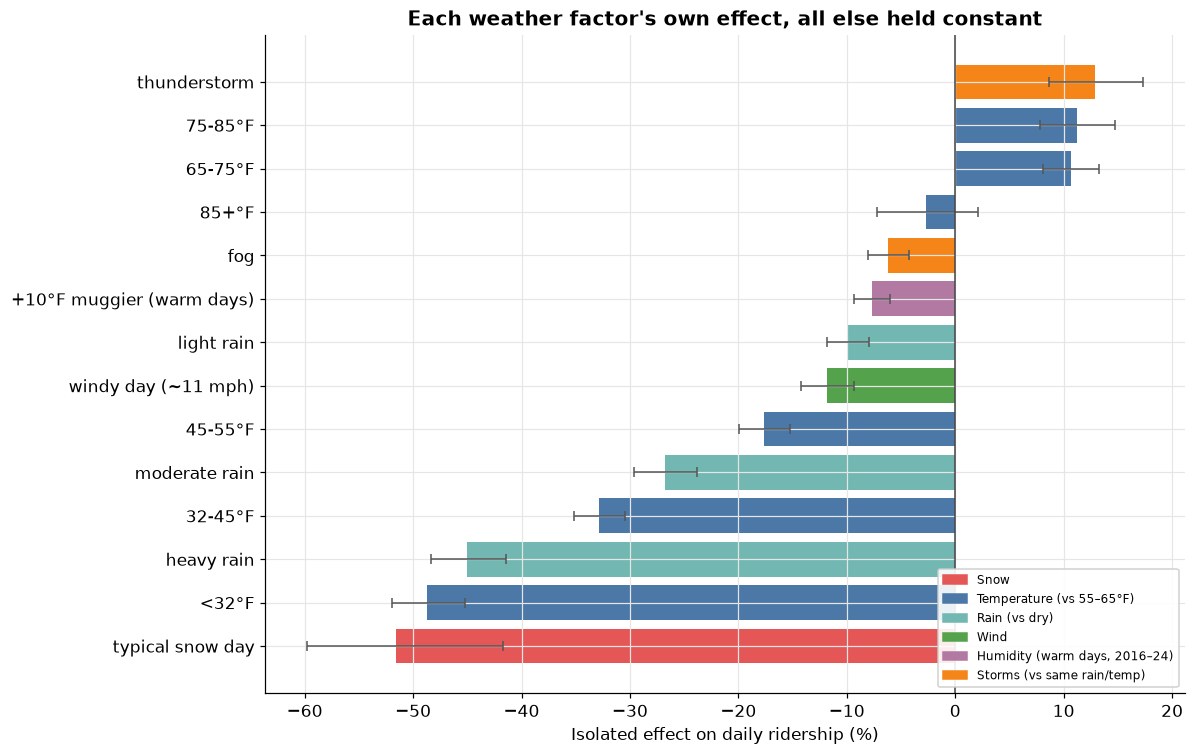

In [18]:
effects_sorted = effects.sort_values("pct")

# One colour per factor group.
groups = effects_sorted["group"].unique()
palette = [RED, BLUE, TEAL, GREEN, PURPLE, ORANGE, NAVY]
group_colour = dict(zip(groups, palette[:len(groups)]))
bar_colours = effects_sorted["group"].map(group_colour)

# Asymmetric error bars: distance from the point estimate to each interval end.
error_low  = effects_sorted["pct"] - effects_sorted["lo"]
error_high = effects_sorted["hi"] - effects_sorted["pct"]

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(effects_sorted))
ax.barh(y, effects_sorted["pct"], color=bar_colours,
        xerr=[error_low, error_high], error_kw=dict(ecolor="#555", lw=1, capsize=3))
ax.axvline(0, color="#444", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(effects_sorted["label"])
ax.set_xlabel("Isolated effect on daily ridership (%)")
ax.set_title("Each weather factor's own effect, all else held constant")

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=group_colour[g]) for g in groups]
ax.legend(legend_handles, groups, fontsize=8, loc="lower right", framealpha=0.9)
plt.show()

**Reading it.** Calendar controls alone already explain the great majority of ridership;
weather then accounts for a meaningful share of *what's left within each month*. Two results
show why isolating matters:

- **Wind** reads ~−22% in the raw view but only about **half** that here — the rest was the
  cold that travels with wind.
- **Thunderstorms** read negative marginally, yet come out **positive** once held to the same
  rain and temperature: strip out the rain a storm brings and what's left are busy, warm
  afternoons. Snow and heavy rain go the *other* way — *stronger* once isolated, because a
  multi-day storm drags down its own monthly baseline, so the naïve comparison understates it.

The 95% whiskers are Newey–West, so they already price in day-to-day autocorrelation.

## 4 · The shape of the day — and what weather does to it

Now the hourly grain. First, descriptively: the day has a rhythm, and that rhythm is two
different products sharing one fleet.

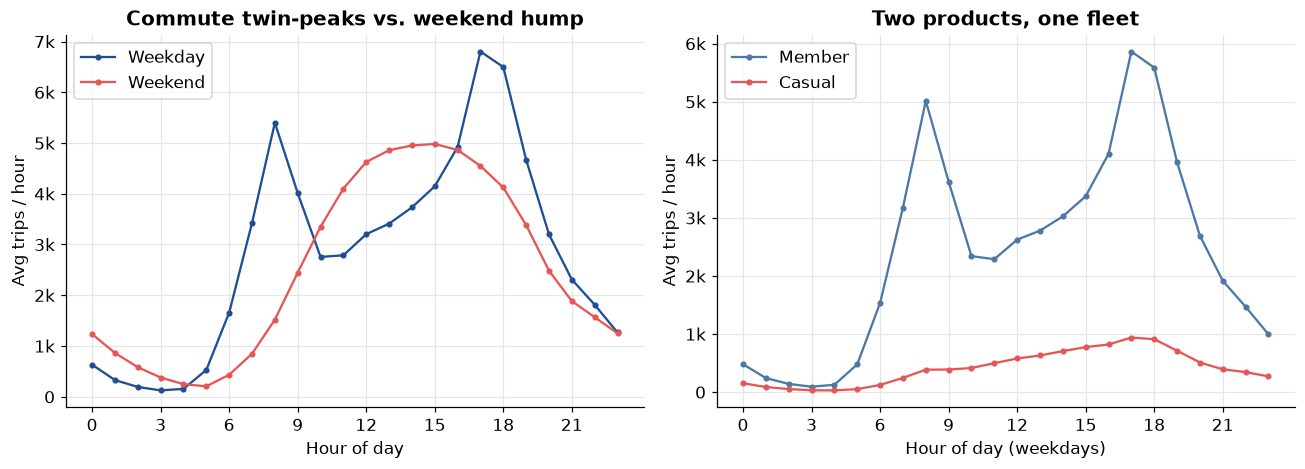

In [19]:
# An hour with zero trips has no row in the mart, so before averaging over hours we
# zero-fill the complete (every date x 0..23) grid. Dropping the empties would
# otherwise inflate the quiet overnight averages.
all_dates = pd.date_range(hourly["date"].min(), hourly["date"].max(), freq="D")
full_grid = pd.MultiIndex.from_product([all_dates, range(24)], names=["date", "hour"])

hourly_counts = (
    hourly.rename(columns={TRIPS: "trips", MEMBER: "member", CASUAL: "casual"})
          .set_index(["date", "hour"])[["trips", "member", "casual"]]
          .reindex(full_grid, fill_value=0.0)
          .reset_index()
)
hourly_counts["is_weekend"] = hourly_counts["date"].dt.dayofweek >= 5

fig, (ax_day, ax_rider) = plt.subplots(1, 2, figsize=(12, 4.4))

# Left: the average daily shape, weekday vs weekend.
for label, mask, colour in [("Weekday", ~hourly_counts["is_weekend"], NAVY),
                            ("Weekend", hourly_counts["is_weekend"], RED)]:
    profile = hourly_counts[mask].groupby("hour")["trips"].mean()
    ax_day.plot(profile.index, profile.values, marker="o", ms=3, color=colour, label=label)
ax_day.set_xlabel("Hour of day")
ax_day.set_ylabel("Avg trips / hour")
ax_day.yaxis.set_major_formatter(thousands)
ax_day.set_xticks(range(0, 24, 3))
ax_day.legend()
ax_day.set_title("Commute twin-peaks vs. weekend hump")

# Right: the same weekday shape split by rider type.
weekday_by_rider = (
    hourly_counts[~hourly_counts["is_weekend"]].groupby("hour")[["member", "casual"]].mean()
)
ax_rider.plot(weekday_by_rider.index, weekday_by_rider["member"],
              marker="o", ms=3, color=BLUE, label="Member")
ax_rider.plot(weekday_by_rider.index, weekday_by_rider["casual"],
              marker="o", ms=3, color=RED, label="Casual")
ax_rider.set_xlabel("Hour of day (weekdays)")
ax_rider.set_ylabel("Avg trips / hour")
ax_rider.yaxis.set_major_formatter(thousands)
ax_rider.set_xticks(range(0, 24, 3))
ax_rider.legend()
ax_rider.set_title("Two products, one fleet")
plt.show()

Weekdays carry the commute signature — twin peaks at 8 am and 5–6 pm — while weekends build
to a single mid-afternoon hump. Splitting by rider type shows why: the twin peaks belong to
**members** (commuters); **casual** riders build to a single afternoon crest, just like the
weekend shape. That structural difference is what the daypart attribution in Section 5 exploits.

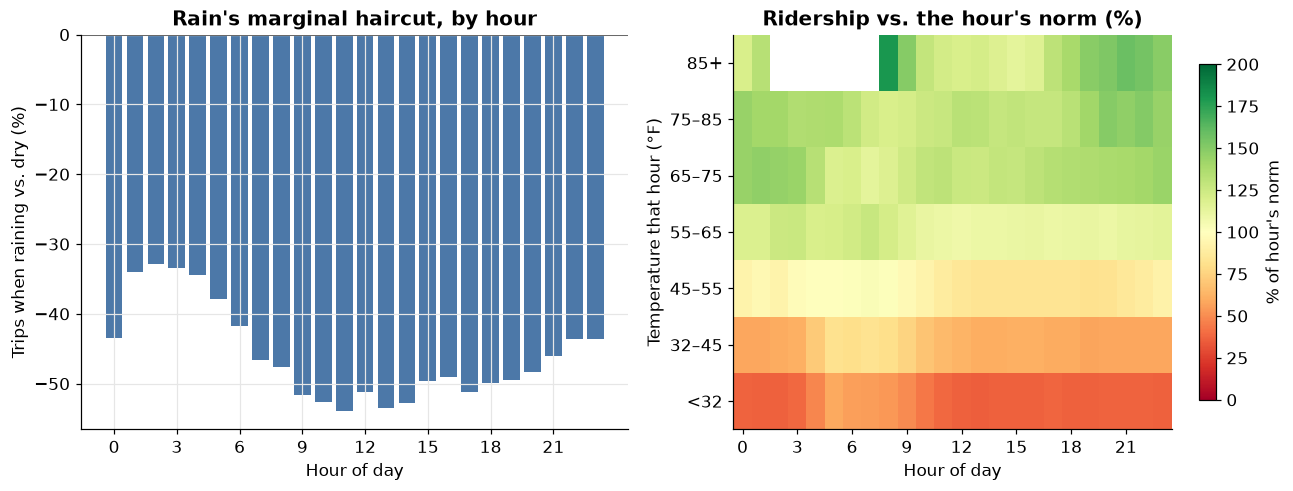

In [20]:
fig, (ax_rain, ax_heat) = plt.subplots(1, 2, figsize=(12, 4.6))

# ---- Left: rain's marginal haircut, by hour of day -------------------------------
# Attach the "raining this hour?" flag to each filled grid cell.
rain_cells = (
    hourly_counts.merge(hourly[["date", "hour", "is_raining"]], on=["date", "hour"], how="left")
                 .dropna(subset=["is_raining"])
)
rain_cells["month"] = rain_cells["date"].dt.month

# Average trips for wet vs dry hours WITHIN each (month, weekend, hour-of-day) cell,
# so we only ever compare like with like (same clock hour, season, day type).
wet_vs_dry = (
    rain_cells.groupby(["month", "is_weekend", "hour", "is_raining"])["trips"].mean()
              .unstack("is_raining")
              .rename(columns={0.0: "dry", 1.0: "wet"})
              .dropna()
)
wet_vs_dry["pct_change"] = (wet_vs_dry["wet"] / wet_vs_dry["dry"] - 1) * 100

# Collapse to one number per hour, weighting each cell by its number of rainy
# observations so thin cells don't dominate.
rainy_obs = (
    rain_cells[rain_cells["is_raining"] == 1.0]
    .groupby(["month", "is_weekend", "hour"]).size()
    .reindex(wet_vs_dry.index).fillna(0.0)
)
weighted_pct = wet_vs_dry["pct_change"].mul(rainy_obs).groupby(level="hour").sum()
haircut_by_hour = weighted_pct / rainy_obs.groupby(level="hour").sum()

ax_rain.bar(haircut_by_hour.index, haircut_by_hour.values, color=BLUE)
ax_rain.axhline(0, color="#444", lw=1)
ax_rain.set_xlabel("Hour of day")
ax_rain.set_ylabel("Trips when raining vs. dry (%)")
ax_rain.set_xticks(range(0, 24, 3))
ax_rain.set_title("Rain's marginal haircut, by hour")

# ---- Right: temperature x hour heatmap -------------------------------------------
# Each cell = average trips at that (temperature band, hour), as a % of the hour's
# all-weather norm, so warm and cold hours are compared on equal footing.
temp_cells = (
    hourly_counts.merge(hourly[["date", "hour", "temp_f"]], on=["date", "hour"], how="left")
                 .dropna(subset=["temp_f"])
)
temp_cells["temp_band"] = pd.cut(
    temp_cells["temp_f"], [-100, 32, 45, 55, 65, 75, 85, 200],
    labels=["<32", "32–45", "45–55", "55–65", "65–75", "75–85", "85+"],
)
avg_by_band_hour = temp_cells.groupby(["temp_band", "hour"], observed=True)["trips"].mean()
avg_by_hour      = temp_cells.groupby("hour")["trips"].mean()
relative_to_hour = (avg_by_band_hour / avg_by_hour * 100).unstack("hour")

heatmap = ax_heat.imshow(relative_to_hour.values, aspect="auto", cmap="RdYlGn",
                         vmin=0, vmax=200, origin="lower")
ax_heat.set_yticks(range(relative_to_hour.shape[0]))
ax_heat.set_yticklabels(relative_to_hour.index)
ax_heat.set_xticks(range(0, 24, 3))
ax_heat.set_xticklabels(range(0, 24, 3))
ax_heat.set_xlabel("Hour of day")
ax_heat.set_ylabel("Temperature that hour (°F)")
ax_heat.set_title("Ridership vs. the hour's norm (%)")
ax_heat.grid(False)
fig.colorbar(heatmap, ax=ax_heat, shrink=0.85, label="% of hour's norm")
plt.show()

The rain bars are a roughly 40–50% haircut whenever it's raining, **deepest in the evening
and overnight leisure hours and shallowest in the morning commute** — riders already
committed to getting to work. The temperature heatmap shows mild-to-warm hours (55–85°F)
running above norm around the clock, while the hottest hours (85°F+) hold up in the evening
but **flatten at midday** — the one part of the day where more heat stops helping.

Both panels are still *descriptive* (temperature bands ride with the seasons; the rain
comparison is marginal). Section 5 turns the rain story into a causal one.

*Note: hours with **literally zero** NYC trips carry no row in the trips mart and so drop out
of this wet-vs-dry comparison — but they're a rounding error here (432 of ~114k cells, just
16 of them rainy, mostly the 2013 launch weeks and a few blizzards). The log-outcome models
in Section 5 likewise require a positive count, so this is an inherent limit of any
ridership-ratio at the hourly grain, not a fixable bias in this chart.*

## 5 · Hourly attribution — rain, by the book

This is where the hourly grain earns its keep. With treatment (rain) varying *within* the
day, we can push the controls one level past the daily model's month effects:

> $$\log(\text{trips}_{d,h}) \;\sim\; \underbrace{\alpha_d}_{\text{day fixed effect}}
> \;+\; C(\text{hour} \times \text{weekend}) \;+\; \beta\,\text{rain}_{d,h} \;+\; \dots$$

**The lessons, made concrete (every one of these is a deliberate design choice):**

1. **Saturated controls at the right resolution → day fixed effects.** A dummy for *every
   calendar day* (4.7k of them, absorbed by within-day demeaning — the within estimator via
   Frisch–Waugh, since 4.7k dense dummies would blow up memory). Growth, season, weekday,
   holidays, **and the day's overall weather** all cancel. Identification is purely
   *within-day*: a raining 8 am against the same day's dry 6 pm, net of the diurnal shape
   (`hour × weekend` controls).
2. **Distributed lags + a cumulative effect.** Rain's drag doesn't end when the rain stops
   (wet streets, lingering showers), so the model carries 4 lags and reports the cumulative
   effect over the raining hour + 4, computed on the *joint* covariance.
3. **Leads as a falsification check.** Two hours *before* the rain carry no wet streets, so
   their coefficient should be ~0. A large lead effect would flag leftover confounding; a
   *small* one reads as anticipation (skies darken, and the gauge stamps rain to the :51 obs).
4. **Nonlinearity via intensity.** A heavy-rain shifter (≥0.10 in/h) lets a downpour bite
   harder than drizzle, at the hourly grain.
5. **Cluster-robust inference.** Standard errors cluster **by day** — hours within a day
   share weather and demand shocks, so per-observation HAC would be far too optimistic.
6. **The member-vs-casual gradient as a validity probe.** Fit the daypart model separately
   for each rider type; a genuine weather response should hit discretionary casual trips
   hardest where riding is optional — a pattern leftover seasonality can't manufacture.

**One scoping note (also a lesson).** Only **rain** is headlined hourly — not for
significance (with 114k rows almost anything is "significant"), but for **identification**.
Under day FE, a temperature coefficient is identified off *within-day* temperature anomalies
(the diurnal cycle, already absorbed) — a different, muddier estimand than the day-level
temperature effect. The warm-vs-cold question lives *between* days, which is exactly the
variation day FE discard and the daily model is built to use. So temperature stays daily;
rain is the factor where the hourly grain genuinely adds identification.

### 5.0 The within-day estimator

Two building blocks, defined once and reused for each rider segment below.

**`build_hourly_model_frame(trips_column)`** assembles the model frame: the log outcome, an
`hour × weekend` key for the diurnal controls, a heavy-rain intensity flag, and — the fiddly
part — rain's **leads and lags** aligned to real clock hours. Zero-trip hours are absent from
the mart, so we reindex onto the *complete* hourly grid before shifting; that way a lag points
at the actual previous clock hour, and hours with missing neighbours drop out rather than
misaligning the event time.

**`fit_with_day_fixed_effects(frame, regressors)`** is the day fixed effect. Rather than build
4.7k day dummies (dense, memory-hungry), we **demean the outcome and every regressor within
each date** — Frisch–Waugh, which gives identical slopes to the full dummy set. Standard errors
**cluster by day**, because hours within a day share weather and demand shocks.

In [21]:
HEAVY_RAIN_IN = 0.10       # >= 0.10 in/hour counts as heavy at the hourly grain
N_LEADS = 2                # hours before the rain (anticipation / falsification)
N_LAGS  = 4                # hours after (wet streets, rebound) -> cumulative effect
# Daypart bands: (first hour, last hour inclusive, label).
HOUR_BANDS = [
    (0, 6, "overnight 12–6a"),
    (7, 9, "AM rush 7–9a"),
    (10, 15, "midday 10a–3p"),
    (16, 19, "PM rush 4–7p"),
    (20, 23, "evening 8–11p"),
]


def build_hourly_model_frame(trips_column):
    """Hourly model frame for one ridership column: log trips, clock keys, rain leads/lags."""
    frame = hourly.copy()
    frame["trips"] = pd.to_numeric(frame[trips_column], errors="coerce").astype(float)

    # A real timestamp per row, so leads/lags can align to actual clock hours.
    frame["timestamp"] = frame["date"] + pd.to_timedelta(frame["hour"], unit="h")
    frame = frame.sort_values("timestamp")

    # Heavy-rain flag (the hourly intensity nonlinearity).
    frame["heavy_rain"] = (
        (frame["is_raining"] == 1) & (frame["prcp_inches"] >= HEAVY_RAIN_IN)
    ).astype(float)

    # Build leads/lags on the COMPLETE hourly grid so a shift lands on the true
    # neighbour hour (zero-trip hours are missing from `frame` and would misalign it).
    complete_grid = pd.date_range(frame["timestamp"].min(), frame["timestamp"].max(), freq="h")
    raining_on_grid = frame.set_index("timestamp")["is_raining"].reindex(complete_grid)
    for k in range(1, N_LEADS + 1):                      # rain k hours in the FUTURE
        frame[f"rain_lead{k}"] = frame["timestamp"].map(raining_on_grid.shift(-k))
    for k in range(1, N_LAGS + 1):                       # rain k hours in the PAST
        frame[f"rain_lag{k}"] = frame["timestamp"].map(raining_on_grid.shift(k))

    # Log outcome -> keep only hours that had at least one trip.
    frame = frame[frame["trips"] > 0].copy()
    frame["log_trips"] = np.log(frame["trips"])

    # Diurnal control key: hour-of-day crossed with weekend (24 x 2 categories).
    is_weekend = (frame["date"].dt.dayofweek >= 5).astype(int)
    frame["hour_x_weekend"] = frame["hour"].astype(str) + "_" + is_weekend.astype(str)
    return frame


def fit_with_day_fixed_effects(frame, regressors):
    """OLS with day fixed effects (within-day demeaning) + hour x weekend, day-clustered SEs.

    Returns (fitted_model, n_days). The day fixed effect is absorbed by subtracting each
    date's mean from the outcome and every regressor (Frisch–Waugh) — identical slopes to
    4.7k explicit day dummies, but cheap. SEs cluster on the date.
    """
    # Diurnal controls as dummies, joined to the rain regressors of interest.
    diurnal_dummies = pd.get_dummies(frame["hour_x_weekend"], prefix="hw", drop_first=True).astype(float)
    design = pd.concat([frame[regressors].astype(float), diurnal_dummies], axis=1)

    # Drop rows with any missing regressor (e.g. a lead/lag at the series edge).
    complete = design.notna().all(axis=1) & frame["log_trips"].notna()
    design = design.loc[complete]
    outcome = frame.loc[complete, "log_trips"]
    day = frame.loc[complete, "date"].values

    # Within-day demeaning = absorb the day fixed effect.
    design_demeaned  = design - design.groupby(day).transform("mean")
    outcome_demeaned = outcome - outcome.groupby(day).transform("mean")

    model = sm.OLS(outcome_demeaned, design_demeaned).fit(
        cov_type="cluster", cov_kwds={"groups": day})
    return model, len(pd.unique(day))


def coefficient_effect(model, name):
    """% effect (with 95% CI) of a single coefficient in a log-outcome model."""
    return pct_from_log_coef(model.params[name], model.bse[name])

### 5.1 An hour of rain leaves a footprint (event-time profile)

Regress log trips on rain at the current hour plus its two **leads** and four **lags**
(carrying `is_snowing` as a control), all under the day fixed effect. The lags trace the
wet-streets decay; the **cumulative** effect over the raining hour + 4 lags is a vector
contrast read off the *joint* covariance.

In [22]:
rain_frame = build_hourly_model_frame(TRIPS)

# Order the event-time terms from earliest lead to latest lag.
lead_terms = [f"rain_lead{k}" for k in range(N_LEADS, 0, -1)]   # rain_lead2, rain_lead1
lag_terms  = [f"rain_lag{k}"  for k in range(1, N_LAGS + 1)]    # rain_lag1 .. rain_lag4
event_terms = lead_terms + ["is_raining"] + lag_terms

profile_model, n_days = fit_with_day_fixed_effects(rain_frame, event_terms + ["is_snowing"])

# Map each term to its event time k: negative = before the rain, 0 = the raining hour.
event_offsets = list(range(-N_LEADS, 0)) + list(range(0, N_LAGS + 1))
profile = pd.DataFrame([
    {"k": k,
     "pct": coefficient_effect(profile_model, term)[0],
     "lo":  coefficient_effect(profile_model, term)[1],
     "hi":  coefficient_effect(profile_model, term)[2]}
    for term, k in zip(event_terms, event_offsets)
])

# Cumulative effect of one raining hour over that hour + its four lags. This is a
# vector contrast (sum of those coefficients), so its SE uses their joint covariance.
cumulative_terms = ["is_raining"] + lag_terms
weights = np.ones(len(cumulative_terms))
cumulative_beta = float(weights @ profile_model.params[cumulative_terms].values)
cumulative_var  = float(
    weights @ profile_model.cov_params().loc[cumulative_terms, cumulative_terms].values @ weights
)
cumulative_pct, cumulative_lo, cumulative_hi = pct_from_log_coef(
    cumulative_beta, np.sqrt(cumulative_var))

print(f"n = {int(profile_model.nobs):,} hours over {n_days:,} days")
print(f"cumulative effect, raining hour + 4 lags: "
      f"{cumulative_pct:.0f}% [{cumulative_lo:.0f}, {cumulative_hi:.0f}] (log terms)\n")

event_labels = {-2: "2h before", -1: "1h before", 0: "raining hour",
                1: "+1h", 2: "+2h", 3: "+3h", 4: "+4h"}
profile["when"] = profile["k"].map(event_labels)
print(profile[["when", "pct", "lo", "hi"]].round(1).to_string(index=False))

n = 112,331 hours over 4,732 days
cumulative effect, raining hour + 4 lags: -61% [-63, -60] (log terms)

        when   pct    lo    hi
   2h before  -4.1  -5.3  -2.9
   1h before -11.7 -12.5 -10.8
raining hour -29.8 -30.6 -29.0
         +1h -25.8 -26.6 -24.9
         +2h -12.6 -13.4 -11.7
         +3h  -8.0  -8.9  -7.1
         +4h  -8.1  -9.3  -6.9


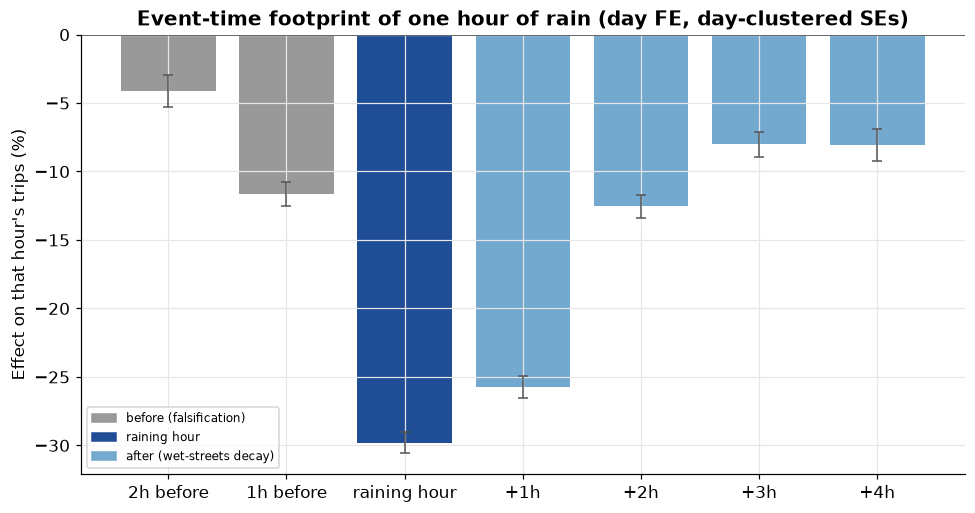

In [23]:
# Colour the bars by phase: grey before the rain, navy for the raining hour, blue after.
def phase_colour(k):
    if k < 0:
        return "#999999"     # before the rain (falsification region)
    if k == 0:
        return NAVY          # the raining hour itself
    return "#74A9CF"         # after the rain (wet-streets decay)

bar_colours = [phase_colour(k) for k in profile["k"]]
error_low  = profile["pct"] - profile["lo"]
error_high = profile["hi"] - profile["pct"]

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(profile))
ax.bar(x, profile["pct"], color=bar_colours,
       yerr=[error_low, error_high], error_kw=dict(ecolor="#555", lw=1, capsize=3))
ax.axhline(0, color="#444", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(profile["when"])
ax.set_ylabel("Effect on that hour's trips (%)")
ax.set_title("Event-time footprint of one hour of rain (day FE, day-clustered SEs)")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#999999"),
    plt.Rectangle((0, 0), 1, 1, color=NAVY),
    plt.Rectangle((0, 0), 1, 1, color="#74A9CF"),
]
ax.legend(legend_handles,
          ["before (falsification)", "raining hour", "after (wet-streets decay)"],
          fontsize=8, loc="lower left")
plt.show()

The raining hour itself takes the biggest hit, and the drag **fades over the next ~4 hours**
— wet streets and lingering showers — summing to most of one average hour's ridership erased
(the cumulative figure printed above). The **leads are the falsification check — and they are
small, but not a clean zero.** With ~112k hours even tiny effects clear significance, and here
two hours ahead is −4% and one hour ahead −12% (both intervals exclude zero). That *gradient*,
growing as the rain nears, is the signature of **anticipation and timestamp attribution** —
skies darken before the first drops, and an hour's rain is stamped to its :51 observation —
rather than of pre-rain wet streets (which would have no mechanism). It is far milder than the
−30% contemporaneous hit, so it doesn't overturn the design; but it's a caveat to carry, not a
test cleanly passed. (A stricter design would model lead-time cloud cover; the daily model,
which has no within-day timestamp ambiguity, is the cross-check.)

### 5.2 Rain by daypart, member vs. casual (the validity probe)

Now interact rain with the **daypart** — each band gets its own rain coefficient — plus the
heavy-rain shifter, all under the same day fixed effect. Fitting it **separately for members
and casual riders** turns the member/casual gap into a falsification test: a real weather
response should bite hardest on discretionary casual trips where riding is optional, a pattern
leftover seasonality (which loads on both alike) can't produce.

In [24]:
def fit_rain_by_daypart(trips_column):
    """Rain x daypart partial effects under day FE, for one ridership column.

    Returns (effects_table indexed by daypart label, heavy-rain % effect).
    """
    frame = build_hourly_model_frame(trips_column)

    # One rain-in-this-daypart indicator per band (rain AND hour in the band's range).
    daypart_regressors = []
    for first_hour, last_hour, label in HOUR_BANDS:
        column = f"rain_{first_hour}_{last_hour}"
        in_band = frame["hour"].between(first_hour, last_hour).astype(float)
        frame[column] = frame["is_raining"] * in_band
        daypart_regressors.append((column, label))

    regressors = [column for column, _ in daypart_regressors] + ["heavy_rain", "is_snowing"]
    model, _ = fit_with_day_fixed_effects(frame, regressors)

    effects_table = pd.DataFrame([
        {"daypart": label,
         "pct": coefficient_effect(model, column)[0],
         "lo":  coefficient_effect(model, column)[1],
         "hi":  coefficient_effect(model, column)[2]}
        for column, label in daypart_regressors
    ]).set_index("daypart")
    heavy_rain_pct = coefficient_effect(model, "heavy_rain")[0]
    return effects_table, heavy_rain_pct


daypart_order = [label for _, _, label in HOUR_BANDS]
member_daypart, _              = fit_rain_by_daypart(MEMBER)
casual_daypart, heavy_rain_pct = fit_rain_by_daypart(CASUAL)
member_daypart = member_daypart.reindex(daypart_order)
casual_daypart = casual_daypart.reindex(daypart_order)

print(f"heavy rain (>= {HEAVY_RAIN_IN:.2f} in/h) adds another "
      f"{heavy_rain_pct:.0f}% on top of light rain\n")
print("Casual:\n", casual_daypart[["pct", "lo", "hi"]].round(1).to_string())
print("\nMember:\n", member_daypart[["pct", "lo", "hi"]].round(1).to_string())

heavy rain (>= 0.10 in/h) adds another -55% on top of light rain

Casual:
                   pct    lo    hi
daypart                          
overnight 12–6a -27.6 -31.0 -24.0
AM rush 7–9a    -45.9 -48.5 -43.1
midday 10a–3p   -61.9 -63.6 -60.1
PM rush 4–7p    -57.6 -59.6 -55.4
evening 8–11p   -54.5 -56.9 -52.1

Member:
                   pct    lo    hi
daypart                          
overnight 12–6a -30.1 -32.2 -27.9
AM rush 7–9a    -41.8 -43.8 -39.7
midday 10a–3p   -45.1 -46.7 -43.4
PM rush 4–7p    -45.5 -47.2 -43.6
evening 8–11p   -44.6 -46.6 -42.6


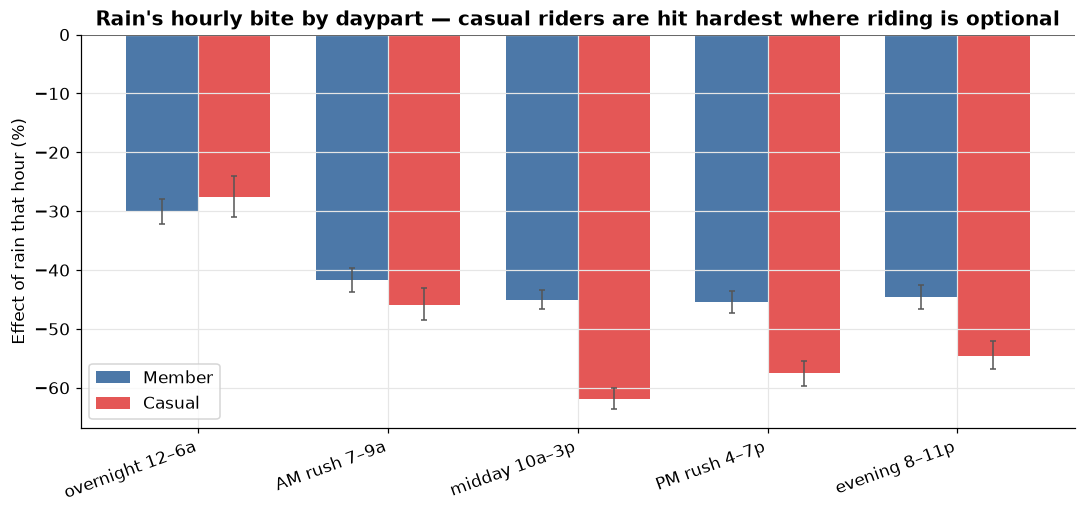

In [25]:
x = np.arange(len(daypart_order))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - bar_width/2, member_daypart["pct"], bar_width, label="Member", color=BLUE,
       yerr=[member_daypart["pct"] - member_daypart["lo"],
             member_daypart["hi"] - member_daypart["pct"]],
       error_kw=dict(ecolor="#555", lw=1, capsize=2))
ax.bar(x + bar_width/2, casual_daypart["pct"], bar_width, label="Casual", color=RED,
       yerr=[casual_daypart["pct"] - casual_daypart["lo"],
             casual_daypart["hi"] - casual_daypart["pct"]],
       error_kw=dict(ecolor="#555", lw=1, capsize=2))
ax.axhline(0, color="#444", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(daypart_order, rotation=20, ha="right")
ax.set_ylabel("Effect of rain that hour (%)")
ax.set_title("Rain's hourly bite by daypart — casual riders are hit hardest where riding is optional")
ax.legend()
plt.show()

**The commute is the least elastic hour** — rain in the AM rush costs the least, riders
already committed to getting to work — while midday and evening discretionary hours lose
roughly half. And the **member/casual gradient is the validity check**: casual riders are hit
hardest exactly where riding is optional (midday), with the gap narrowing in the commute.
That's the elasticity pattern a real behavioral response should show, and one leftover
seasonality could *not* manufacture — seasonality would load on both segments alike. A
heavy-rain shifter deepens the light-rain effect further still.

### 5.3 Reading the two grains together

> **The hour-level losses are deliberately *bigger* than the daily rain bars** — and that gap
> is informative, not a contradiction. The hourly model's day fixed effect nets out trips that
> simply **shifted to a drier hour of the same day**; the daily model nets that displacement
> *back in*. So:
> - the **daily** rain coefficient ≈ the **net** loss for the day (after within-day shifting),
> - the **hourly** rain coefficient ≈ the **at-the-moment** loss (shifting included).
>
> Together they **bracket** how much of rain's hit is true lost demand versus riders just
> waiting out the shower — exactly the decomposition the distributed-lag literature is built
> to deliver.

## 6 · Putting it to work — weather-adjusted ridership

The same machinery becomes an operator KPI. Instead of month fixed effects, predict the trips
you'd **expect for each day's weather and time of year**, then contrast the actual weather
against the day-of-year *climatological normal*. The residual is a **weather-adjusted**
ridership: true year-over-year growth, net of whether the season ran warm/dry or cool/wet.

The model is the same `log(trips) ~ month-FE + calendar + weather` shape, with temperature as
a smooth **B-spline** (`bs(tavg_f, df=5)`) and precip/snow **capped** (past ~1.25 in rain /
6 in snow the system is already at its weather floor). We fit it once, predict each day twice
— at its *actual* weather and at the day-of-year *climatological normal* — and the ratio of
those predictions is the day's weather lift/drag; dividing it out gives weather-adjusted trips.

In [26]:
# Weather drivers that get a day-of-year "normal" (and so can be swapped to climatology).
KPI_WEATHER = ["tavg_f", "wind_avg_mph", "prcp_cap", "rain_flag", "snow_cap",
               "snow_depth_inches", "is_thunder", "is_foggy"]
KPI_FORMULA = (
    "log_trips ~ C(year_month) + C(day_of_week) + holiday"
    " + bs(tavg_f, df=5) + wind_avg_mph"
    " + prcp_cap + rain_flag + snow_cap + snow_depth_inches + is_thunder + is_foggy"
)

kpi_df = daily[daily[TRIPS] > 0].sort_values("date").reset_index(drop=True).copy()
kpi_df["log_trips"]   = np.log(kpi_df[TRIPS])
kpi_df["year_month"]  = kpi_df["date"].dt.year * 12 + kpi_df["date"].dt.month
kpi_df["day_of_week"] = kpi_df["date"].dt.dayofweek
kpi_df["day_of_year"] = kpi_df["date"].dt.dayofyear
kpi_holidays = USFederalHolidayCalendar().holidays(kpi_df["date"].min(), kpi_df["date"].max())
kpi_df["holiday"] = kpi_df["date"].isin(kpi_holidays).astype(int)

# Cap heavy precip/snow (past the floor the system is shut regardless) and add a rain flag.
kpi_df["prcp_cap"]  = kpi_df["prcp_inches"].clip(0, 1.25)
kpi_df["rain_flag"] = np.where(kpi_df["prcp_inches"].isna(), np.nan,
                               (kpi_df["prcp_inches"] > 0).astype(float))
kpi_df["snow_cap"]  = kpi_df["snow_inches"].clip(0, 6.0)

**Day-of-year climatology.** For each weather driver we compute a smoothed "normal" value for
every calendar day — the mean across years, then a circular 15-day rolling average so Dec 31
and Jan 1 join up. We use it for two things: (1) to impute any *unreported* weather as
seasonally neutral (never a fabricated dry day), and (2) as the counterfactual "normal
weather" we compare each day against.

In [27]:
def day_of_year_normal(frame, column):
    """Smoothed climatological normal of `column` for each day-of-year (1..366)."""
    by_doy = (
        frame.groupby("day_of_year")[column].mean()
             .reindex(range(1, 367))
             .interpolate(limit_direction="both")
    )
    # Tile three copies so a centered 15-day window wraps around the year-end, then
    # keep the middle copy.
    wrapped = pd.concat([by_doy, by_doy, by_doy])
    smoothed = wrapped.rolling(15, center=True, min_periods=1).mean().iloc[366:732]
    smoothed.index = range(1, 367)
    return smoothed

climatology = {column: day_of_year_normal(kpi_df, column) for column in KPI_WEATHER}

# Impute unreported weather from climatology (seasonally neutral, not a fake dry day).
for column in KPI_WEATHER:
    kpi_df[column] = kpi_df[column].fillna(kpi_df["day_of_year"].map(climatology[column]))

kpi_model = smf.ols(KPI_FORMULA, data=kpi_df).fit()

# Predict each day twice: once at its ACTUAL weather, once at the seasonal NORMAL.
predicted_actual = kpi_model.predict(kpi_df)
normal_weather_df = kpi_df.copy()
for column in KPI_WEATHER:
    normal_weather_df[column] = kpi_df["day_of_year"].map(climatology[column])
predicted_normal = kpi_model.predict(normal_weather_df)

# weather_effect = how much the day's weather lifted (+) or dragged (−) ridership;
# adjusted = the trips you'd have seen under normal weather.
adjusted = pd.DataFrame({
    "date": kpi_df["date"].values,
    "actual": kpi_df[TRIPS].values,
    "weather_effect": (np.exp(predicted_actual - predicted_normal) - 1).values,
})
adjusted["adjusted"] = adjusted["actual"] / (1 + adjusted["weather_effect"])
adjusted["year"] = adjusted["date"].dt.year
adjusted.head()

,date,actual,weather_effect,adjusted,year
0,2013-06-01,8722.0,0.120467,7784.254858,2013
1,2013-06-02,15971.0,-0.377805,25668.806533,2013
2,2013-06-03,7598.0,-0.353370,11750.150875,2013
3,2013-06-04,15782.0,0.086950,14519.527717,2013
4,2013-06-05,15690.0,0.090631,14386.163042,2013


Aggregate to near-complete years and chart each year's weather luck.

      actual  adjusted  weather_pct
year                               
2014     8.1       8.4         -4.2
2015     9.9      10.1         -1.6
2016    13.8      13.7          0.9
2017    16.4      16.1          1.8
2018    18.9      19.8         -4.8
2019    20.6      20.8         -1.4
2020    19.5      18.9          3.0
2021    27.1      26.9          0.7
2022    30.7      30.6          0.3
2023    36.2      34.9          3.7
2024    44.4      42.1          5.4
2025    45.8      45.4          0.8


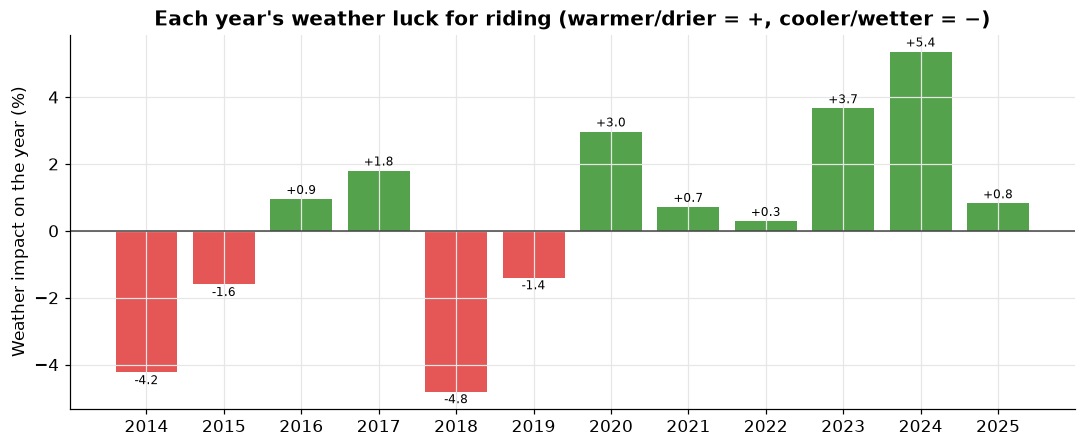

In [28]:
# Keep years with enough covered days that annual totals are comparable.
by_year = adjusted.groupby("year").agg(
    actual=("actual", "sum"),
    adjusted=("adjusted", "sum"),
    days=("date", "size"),
)
by_year = by_year[by_year["days"] >= 300]
by_year["weather_pct"] = (by_year["actual"] / by_year["adjusted"] - 1) * 100

print(by_year.assign(
    actual=(by_year["actual"] / 1e6).round(1),
    adjusted=(by_year["adjusted"] / 1e6).round(1),
    weather_pct=by_year["weather_pct"].round(1),
)[["actual", "adjusted", "weather_pct"]])

fig, ax = plt.subplots(figsize=(10, 4.2))
bar_colours = np.where(by_year["weather_pct"] >= 0, GREEN, RED)
ax.bar(by_year.index.astype(int).astype(str), by_year["weather_pct"], color=bar_colours)
ax.axhline(0, color="#444", lw=1)
ax.set_ylabel("Weather impact on the year (%)")
ax.set_title("Each year's weather luck for riding (warmer/drier = +, cooler/wetter = −)")
for position, value in zip(range(len(by_year)), by_year["weather_pct"]):
    ax.text(position, value + (0.15 if value >= 0 else -0.35),
            f"{value:+.1f}", ha="center", fontsize=8)
plt.show()

Positive years ran warmer/drier than their seasonal norm (a tailwind for ridership), negative
years cooler/wetter. Subtracting this column from raw year-over-year growth leaves the part
that's real demand — the apples-to-apples number for targets and forecasts.

## 7 · Methodology recap — the lessons in one place

| Lesson | Daily model | Hourly model |
|---|---|---|
| **Strip growth + season** | month fixed effects (within-month identification) | **day** fixed effects (within-day identification) |
| **Diurnal shape** | — (one obs/day) | `hour × weekend` controls |
| **Nonlinear weather** | temperature & rain **binned** | heavy-rain (≥0.10 in/h) shifter |
| **Dynamics** | snow-depth term (multi-day) | distributed **lags** + cumulative effect |
| **Falsification** | thunder/fog held to same rain & temp | rain **leads** (small, flagged as anticipation) |
| **Honest inference** | Newey–West (HAC) for serial corr. | SEs **clustered by day** |
| **Validity probe** | casual-share descriptives | member-vs-casual elasticity gradient |
| **Estimand** | net **level** effects (temp, wind, humidity, snow, daily rain) | **timing** effect of rain (incl. within-day displacement) |

**The throughline.** Match the controls to the resolution of the variation you have:
between-day weather shocks identify the *level* effects (daily, month FE), within-day rain
bursts identify the *timing* effect (hourly, day FE). Bin what's nonlinear, lag what persists,
put a falsification term where you can, cluster errors at the level shocks are shared, and keep
one variable (member vs. casual) as a behavioral check the design has to pass. Read the two
grains *together*: the daily coefficient is the net day effect, the hourly one is the
at-the-moment effect, and the difference is within-day displacement.

*Every model above is built inline in this notebook with `statsmodels`. The Streamlit dashboard
packages the identical estimators in `dashboard/attribution.py` for production use, so the live
app and this narrative report the same numbers.*